In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime #Para manejar el tiempo

In [2]:
data = pd.read_csv("Accidentalidad_en_Barranquilla_20260602.csv")
data.head(5)

,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,01:30:00:am,Con heridos,Atropello,CL 87 9H 24,1.0,NaN,1,2018,January,Mon
1,2018-01-01T00:00:00.000,02:00:00:pm,Solo daños,Choque,CL 110 CR 46,NaN,NaN,1,2018,January,Mon
2,2018-01-01T00:00:00.000,04:00:00:am,Solo daños,Choque,AV CIRCUNVALAR CR 9G,NaN,NaN,1,2018,January,Mon
3,2018-01-01T00:00:00.000,04:30:00:am,Solo daños,Choque,CLLE 72 CRA 29,NaN,NaN,1,2018,January,Mon
4,2018-01-01T00:00:00.000,05:20:00:pm,Solo daños,Choque,VIA 40 CALLE 75,NaN,NaN,1,2018,January,Mon


In [3]:
## A qué hora ocurren más accidentes, qué día de la semana, que día del mes, qué mes? DOnde ocurren más accidentes?, muertes por accidentes?

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28328 entries, 0 to 28327
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   FECHA_ACCIDENTE                   28328 non-null  str    
 1   HORA_ACCIDENTE                    28328 non-null  str    
 2   GRAVEDAD_ACCIDENTE                28328 non-null  str    
 3   CLASE_ACCIDENTE                   28328 non-null  str    
 4   SITIO_EXACTO_ACCIDENTE            28328 non-null  str    
 5   CANT_HERIDOS_EN _SITIO_ACCIDENTE  12641 non-null  float64
 6   CANT_MUERTOS_EN _SITIO_ACCIDENTE  328 non-null    float64
 7   CANTIDAD_ACCIDENTES               28328 non-null  int64  
 8   AÑO_ACCIDENTE                     28328 non-null  int64  
 9   MES_ACCIDENTE                     28328 non-null  str    
 10  DIA_ACCIDENTE                     28328 non-null  str    
dtypes: float64(2), int64(2), str(7)
memory usage: 2.4 MB


## Por ahora se decide no lidiar con los valores nulos

<Axes: xlabel='AÑO_ACCIDENTE', ylabel='count'>

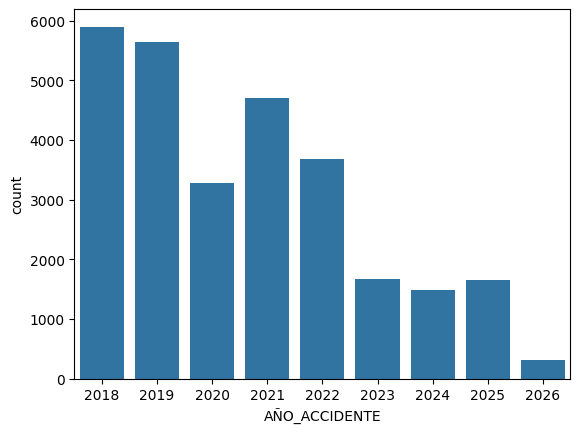

In [5]:
## Distribución de año de registro de los accidentes

sns.countplot(data=data, x="AÑO_ACCIDENTE")

### Más accidentes en anteriores años o simplemente más registro?

In [6]:
data["HORA_ACCIDENTE"] = data["HORA_ACCIDENTE"].apply(lambda x: datetime.strptime(x, "%I:%M:%S:%p")) #Usa la libreria para transforar la hora
# data["HORA_ACCIDENTE"] = data["HORA_ACCIDENTE"].apply(lambda x: datetime.strftime(x, "%H:%M:%S")) # A 24 horas
data.head(3)

,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,1900-01-01 01:30:00,Con heridos,Atropello,CL 87 9H 24,1.0,NaN,1,2018,January,Mon
1,2018-01-01T00:00:00.000,1900-01-01 14:00:00,Solo daños,Choque,CL 110 CR 46,NaN,NaN,1,2018,January,Mon
2,2018-01-01T00:00:00.000,1900-01-01 04:00:00,Solo daños,Choque,AV CIRCUNVALAR CR 9G,NaN,NaN,1,2018,January,Mon


<Axes: xlabel='HORA_ACCIDENTE', ylabel='count'>

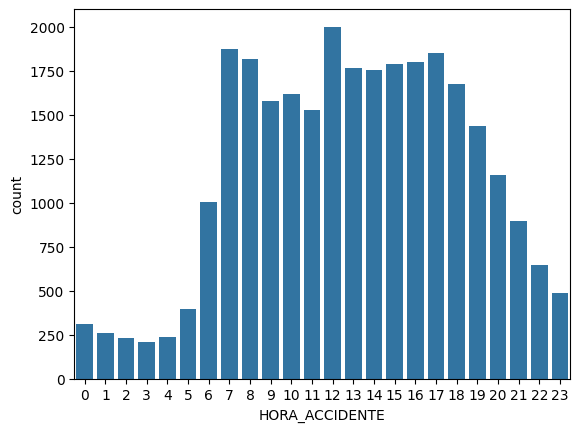

In [7]:
sns.countplot(data=data, x=data["HORA_ACCIDENTE"].dt.hour)

### Picos a las 7, 12 y 17.

In [8]:
data["DIA_ACCIDENTE"].unique()

<StringArray>
['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun', 'Jue', 'Vie', 'Sáb', 'Dom',
 'Lun', 'Mar', 'Mié']
Length: 14, dtype: str

### Días no estandarizados, (inglés y español). Voy a hacer que todos sean en español.

In [35]:
dias_ingles = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dias_espanol = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

data["DIA_ACCIDENTE"] = data["DIA_ACCIDENTE"].replace(dias_ingles, dias_espanol)
data.head(5)

,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,1900-01-01 01:30:00,Con heridos,Atropello,CL 87 9H 24,1.0,NaN,1,2018,January,Lun
1,2018-01-01T00:00:00.000,1900-01-01 14:00:00,Solo daños,Choque,CL 110 CR 46,NaN,NaN,1,2018,January,Lun
2,2018-01-01T00:00:00.000,1900-01-01 04:00:00,Solo daños,Choque,AV CIRCUNVALAR CR 9G,NaN,NaN,1,2018,January,Lun
3,2018-01-01T00:00:00.000,1900-01-01 04:30:00,Solo daños,Choque,CLLE 72 CRA 29,NaN,NaN,1,2018,January,Lun
4,2018-01-01T00:00:00.000,1900-01-01 17:20:00,Solo daños,Choque,VIA 40 CALLE 75,NaN,NaN,1,2018,January,Lun


<Axes: xlabel='DIA_ACCIDENTE', ylabel='count'>

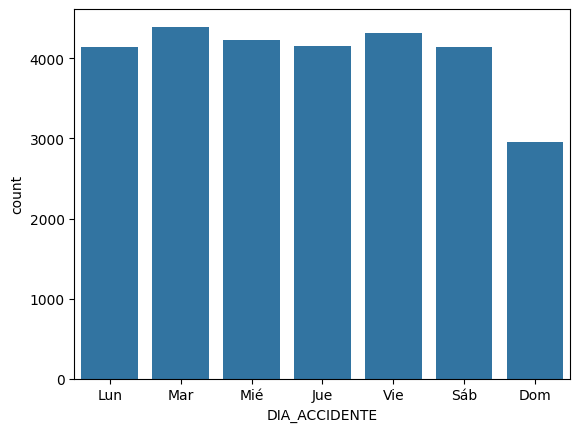

In [36]:
# Acumulados de accidente por dia de semana
sns.countplot(data=data, x="DIA_ACCIDENTE")

In [37]:
data["MES_ACCIDENTE"].unique()

<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December',
     'Enero',   'Febrero',     'Marzo']
Length: 15, dtype: str

In [38]:
## Mover todos los datos a español
meses_ingles = ["January", "February", "March", "April", "May", "June", 
                "July", "August", "September", "October", "November", "December"]

meses_espanol = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", 
                 "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

data["MES_ACCIDENTE"] = data["MES_ACCIDENTE"].replace(meses_ingles, meses_espanol)

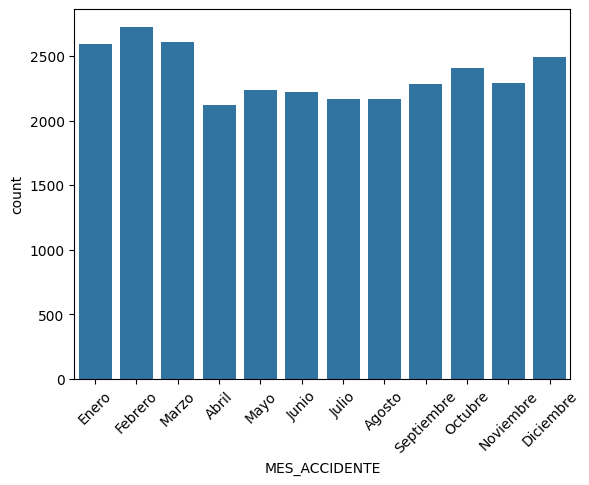

In [42]:
# Días del mes donde hay más accidentes
sns.countplot(data=data, x="MES_ACCIDENTE")
plt.xticks(rotation=45)
plt.show()

In [11]:
data["SITIO_EXACTO_ACCIDENTE"].unique()

<StringArray>
[                                   'CL 87 9H 24',
                                   'CL 110 CR 46',
                           'AV CIRCUNVALAR CR 9G',
                                 'CLLE 72 CRA 29',
                                'VIA 40 CALLE 75',
                                     'CR 8 CL 41',
                              'CLLE 119B CRA 11B',
                               'CARRERA 25 37-42',
                                   'CR 51B 1D 35',
                                'VIA 40  CLLE 85',
 ...
 'CALLE 30 CRA 26 FRENTE DEL LOCAL CARPIN CENTRO',
                                'CALLE 93 CRA 43',
                            'CRA 9D N° CALLE 53A',
                             'CALLE 115 N°2 -399',
                              'CALLE 102 CRA 49E',
                                'CALLE 76 CRA 48',
                               'CRA 6B CALLE 35A',
                                'CALLE 40 CRA 8H',
                                'CALLE 70 CRA 34',
            

In [12]:
hot_spots = data["SITIO_EXACTO_ACCIDENTE"].value_counts().head(6)
hot_spots

SITIO_EXACTO_ACCIDENTE
CL 110 CR 9G    77
CL 110 CR 6     66
CL 110 CR 43    55
CL 30 CR 8      53
VIA 40 CL 85    53
CL 17 CR 8      53
Name: count, dtype: int64

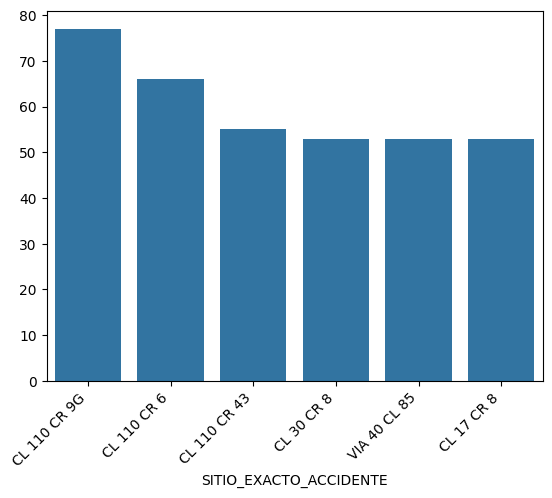

In [32]:
sns.barplot(x=hot_spots.index, y=hot_spots.values)
plt.xticks(rotation=45, ha="right")
plt.show()